In [32]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")


import core


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Define configuration



In [33]:
SYSTEM = {
    # Model parameters
    "A": np.array([[1.15, 0.1], 
                   [0.0, 1.05]]),
    "B": np.array([[1.0], 
                   [0.5]]),
    "C": np.array([[1.0, 0.5]]),
    # Weight matrices
    "Q": np.eye(2),
    "R": np.array([[0.30]]),
    "QN": np.eye(2),
    # Noise statistics
    "Sigma_w": np.array([[0.05, 0.0], 
                         [0.0, 0.05]]),
    "x_ini": np.array([[1.0], 
                       [-1.0]]),
    "Sigma_ini": np.array([[0.20, 0.0], 
                           [0.0, 0.20]]),
}

PRIVACY = {
    # Privacy parameters
    "epsilon": math.log(2),
    "delta": 0.5,
    # Adjacency parameter
    "gamma": 0.5,
    # Ratio between lower and upper bounds of sigma^2 and b
    "rho_sigma": 1.2,
    "rho_b": 1.2,
}

SIM = {
    # Prediction horizon
    "N": 20,
    # Simulation repetition number
    "n_mc": 10000,     
    # Grid of parameters for plotting Fig. 2
    "n_grid": 12,     
    # Noise seed
    "seed_gaussian": 123,
    "seed_laplace": 456,
}

# Grid of tau for plotting Fig. 1
TAU_GRID = np.logspace(-2, 2, 800)
MEASUREMENT_DIM = SYSTEM["C"].shape[0] # = p
KL_HORIZON_LENGTH = MEASUREMENT_DIM * (SIM["N"] + 1) # = L


## 2. Pre-computation
- Compute noise parmeter lower bound (Lemma 1)
- Build the ambiguity set $\Xi$ 
- Compute $\eta$ (Theorem 1)

In [34]:
# Compute lower bounds in Lemma 1
sigma2_lb, b_lb = core.privacy_lower_bounds_vector(
    C=SYSTEM["C"],
    epsilon=PRIVACY["epsilon"],
    delta=PRIVACY["delta"],
    gamma=PRIVACY["gamma"],
)

# Set empirical upper bounds
sigma2_ub = PRIVACY["rho_sigma"] * sigma2_lb
b_ub = PRIVACY["rho_b"] * b_lb

# Compute eta
eta, eta1, eta2 = core.kl_radius_vector(
    sigma2_nom=sigma2_lb,
    sigma2_ub=sigma2_ub,
    b_lb=b_lb,
    b_ub=b_ub,
    L=KL_HORIZON_LENGTH,
)

- Controller Synthesis and computation of $\tau^*$

In [35]:
# Nominal LQG controller synthesis
nominal_lqg = core.synthesize_nominal_lqg_vector(
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], Sigma_ini=SYSTEM["Sigma_ini"],
    sigma2_nom=sigma2_lb, N=SIM["N"],
)

# Compute optimal tau* in Theorem 2
tau_solution, tau_objective_curve = core.synthesize_minimax_closed_form_vector(
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
    sigma2_nom=sigma2_lb, N=SIM["N"], eta=eta,
    tau_grid=TAU_GRID,
)

# Feasibility check
if tau_solution is None:
    raise RuntimeError("No feasible tau was found on the grid. Try enlarging the tau grid or relaxing the toy setup.")

# Proposed controller synthesis 
minimax_ctrl = tau_solution["controller"]

In [36]:
core.print_closed_form_report(
    sigma2_lb=sigma2_lb,
    b_lb=b_lb,
    sigma2_ub=sigma2_ub,
    b_ub=b_ub,
    eta1=eta1,
    eta2=eta2,
    eta=eta,
    selected_tau=minimax_ctrl["tau"],
    objective=tau_solution["objective"],
)

Lower bounds from Lemma 1
  sigma^2 lower bound : 1.191962
  b lower bound       : 0.721348

Upper bounds chosen empirically
  sigma^2 upper bound : 1.430354
  b upper bound       : 0.865617

KL-ball radius from Theorem 1
  eta1 = 0.017678
  eta2 = 0.173052
  eta  = 1.817042

Selected tau = 28.139193
Best outer objective of (17) = 119.425278


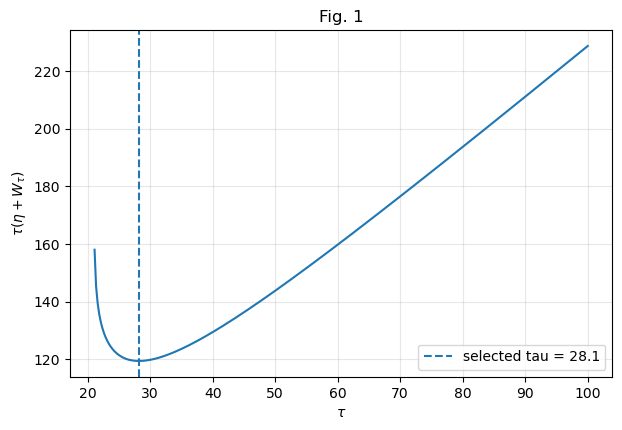

In [37]:
# Plot of tau
core.plot_tau_objective(TAU_GRID, tau_objective_curve, minimax_ctrl["tau"])

## 3. Plotting Fig. 2
- Compare performance of standard LQG and proposed method
- Plots average, 95th percentile, and worst-case values of $J(\mathcal{K})$

In [38]:
# Parmeter grid
gaussian_grid = np.linspace(sigma2_lb, sigma2_ub, SIM["n_grid"])
laplace_grid = np.linspace(b_lb, b_ub, SIM["n_grid"])

# Evaluation for Gaussian mechanism
gaussian_minimax = core.evaluate_grid(
    controller=minimax_ctrl,
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
    noise_family="gaussian", param_grid=gaussian_grid,
    N=SIM["N"], n_mc=SIM["n_mc"], seed=SIM["seed_gaussian"],
)

gaussian_lqg = core.evaluate_grid(
    controller=nominal_lqg,
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
    noise_family="gaussian", param_grid=gaussian_grid,
    N=SIM["N"], n_mc=SIM["n_mc"], seed=SIM["seed_gaussian"],
)

# Evaluation for Laplace mechanism
laplace_minimax = core.evaluate_grid(
    controller=minimax_ctrl,
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
    noise_family="laplace", param_grid=laplace_grid,
    N=SIM["N"], n_mc=SIM["n_mc"], seed=SIM["seed_laplace"],
)

laplace_lqg = core.evaluate_grid(
    controller=nominal_lqg,
    A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
    Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
    Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
    noise_family="laplace", param_grid=laplace_grid,
    N=SIM["N"], n_mc=SIM["n_mc"], seed=SIM["seed_laplace"],
)



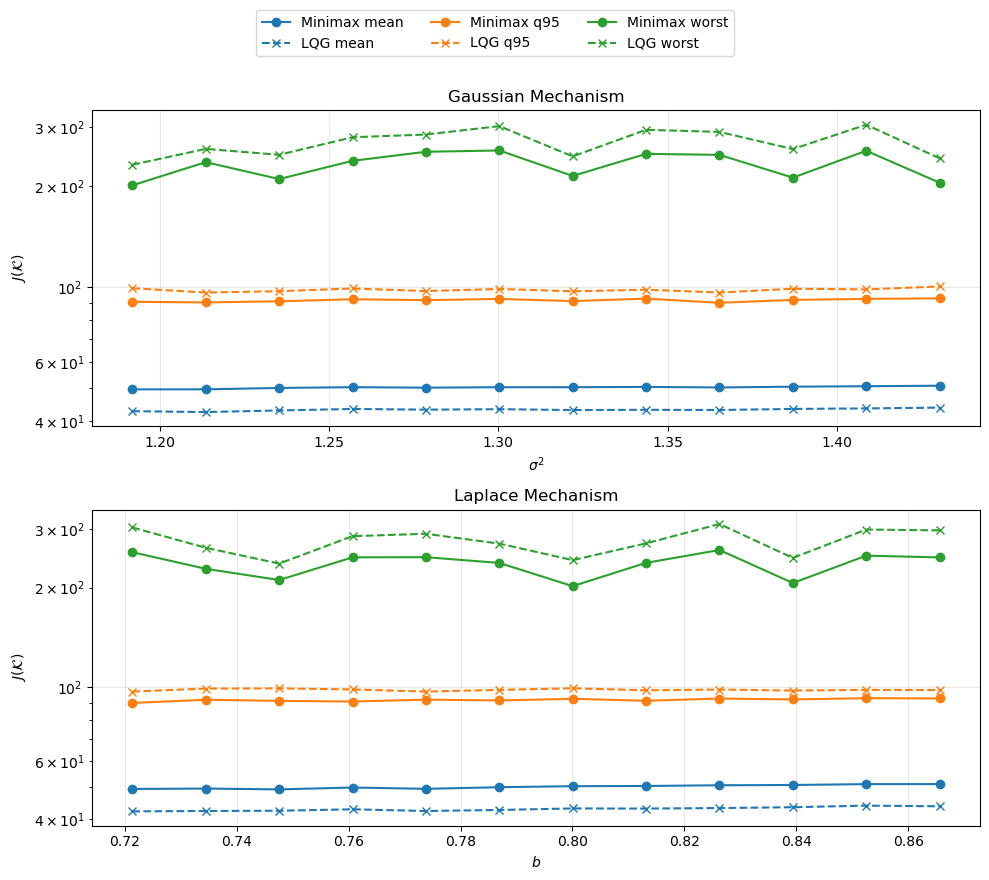

In [39]:
core.plot_all_metrics_two_by_one(
    gauss_mm=gaussian_minimax,
    gauss_lqg=gaussian_lqg,
    lap_mm=laplace_minimax,
    lap_lqg=laplace_lqg,
)

## 3. Plotting Fig. 3
- Performance comparison under varying privacy parameters

In [40]:
# deltas to test
DELTA_SWEEP = [0.01, 0.1, 0.5]
# epsilons to test
EPSILON_SWEEP = np.linspace(math.log(2), 1.0, 100)
# Number of repetitions
N_MC_PRIVACY_SWEEP = 10000

rows = []

for delta_val in DELTA_SWEEP:
    for epsilon_val in EPSILON_SWEEP:
        # For each privacy parameter set, choose \underline{\sigma}^2 as the lower bound in Lemma 1
        sigma2_lb_sweep, b_lb_sweep = core.privacy_lower_bounds_vector(
            C=SYSTEM["C"],
            epsilon=float(epsilon_val),
            delta=float(delta_val),
            gamma=PRIVACY["gamma"],
        )

        # Fix the ratio between lower and upper bounds
        sigma2_ub_sweep = PRIVACY["rho_sigma"] * sigma2_lb_sweep
        b_ub_sweep = PRIVACY["rho_b"] * b_lb_sweep

        # Compute eta
        eta_sweep, _, _ = core.kl_radius_vector(
            sigma2_nom=sigma2_lb_sweep,
            sigma2_ub=sigma2_ub_sweep,
            b_lb=b_lb_sweep,
            b_ub=b_ub_sweep,
            L=KL_HORIZON_LENGTH,
        )

        # Compute tau*
        tau_solution_sweep, _ = core.synthesize_minimax_closed_form_vector(
            A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
            Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
            Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
            sigma2_nom=sigma2_lb_sweep, N=SIM["N"], eta=eta_sweep,
            tau_grid=TAU_GRID,
        )

        if tau_solution_sweep is None:
            rows.append({
                "delta": float(delta_val),
                "epsilon": float(epsilon_val),
                "mechanism": "Gaussian",
                "mean_cost": np.nan,
            })
            rows.append({
                "delta": float(delta_val),
                "epsilon": float(epsilon_val),
                "mechanism": "Laplace",
                "mean_cost": np.nan,
            })
            continue

        # Controller synthesis
        minimax_ctrl_sweep = tau_solution_sweep["controller"]

        # Compute costs for Gaussian mechanism
        gaussian_costs = core.simulate_controller_vector_vectorized(
            controller=minimax_ctrl_sweep,
            A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
            Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
            Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
            noise_family="gaussian", noise_param=sigma2_lb_sweep,
            N=SIM["N"], n_mc=N_MC_PRIVACY_SWEEP, seed=SIM["seed_gaussian"],
        )
        rows.append({
            "delta": float(delta_val),
            "epsilon": float(epsilon_val),
            "mechanism": "Gaussian",
            "mean_cost": float(np.mean(gaussian_costs)),
        })

        # Compute costs for Laplace mechanism
        laplace_costs = core.simulate_controller_vector_vectorized(
            controller=minimax_ctrl_sweep,
            A=SYSTEM["A"], B=SYSTEM["B"], C=SYSTEM["C"],
            Q=SYSTEM["Q"], R=SYSTEM["R"], QN=SYSTEM["QN"],
            Sigma_w=SYSTEM["Sigma_w"], x_ini=SYSTEM["x_ini"], Sigma_ini=SYSTEM["Sigma_ini"],
            noise_family="laplace", noise_param=b_lb_sweep,
            N=SIM["N"], n_mc=N_MC_PRIVACY_SWEEP, seed=SIM["seed_laplace"],
        )
        rows.append({
            "delta": float(delta_val),
            "epsilon": float(epsilon_val),
            "mechanism": "Laplace",
            "mean_cost": float(np.mean(laplace_costs)),
        })




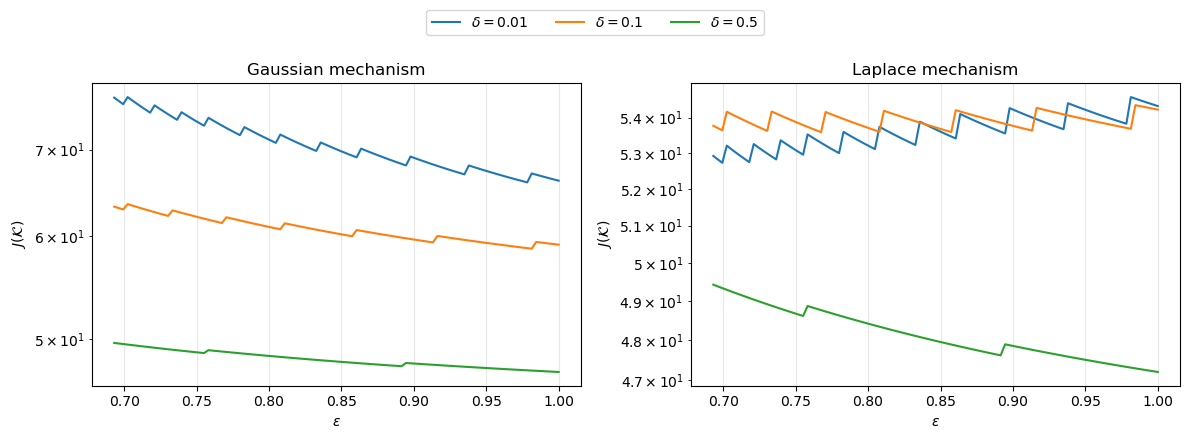

In [41]:

privacy_sweep_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=False)
mechanisms = ["Gaussian", "Laplace"]
colors = ["C0", "C1", "C2"]

for ax, mechanism in zip(axes, mechanisms):
    df_mech = privacy_sweep_df[privacy_sweep_df["mechanism"] == mechanism]
    for color, delta_val in zip(colors, DELTA_SWEEP):
        df_line = df_mech[df_mech["delta"] == float(delta_val)].sort_values("epsilon")
        ax.plot(
            df_line["epsilon"],
            df_line["mean_cost"],
            color=color,
            label=fr"$\delta = {delta_val}$",
        )

    ax.set_title(f"{mechanism} mechanism")
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$J(\mathcal{K})$")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=3)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.88))
plt.show()
